In [49]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [52]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20

TRAIN_DIR = "../dataset/train/images"
VAL_DIR = "../dataset/validation/images"

In [53]:
for folder in os.listdir(TRAIN_DIR):
    path = os.path.join(TRAIN_DIR, folder)

    if os.path.isdir(path):
        print(folder, ":", len(os.listdir(path)))

crazing : 240
inclusion : 240
patches : 240
pitted_surface : 240
rolled_in_scale : 240
scratches : 240


In [54]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=25,

    zoom_range=0.25,

    width_shift_range=0.15,

    height_shift_range=0.15,

    shear_range=0.15,

    brightness_range=[0.8,1.2],

    horizontal_flip=True,

    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [55]:
train_data = train_datagen.flow_from_directory(

    TRAIN_DIR,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True
)

Found 1440 images belonging to 6 classes.


In [57]:
val_data = val_datagen.flow_from_directory(

    VAL_DIR,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

Found 360 images belonging to 6 classes.


In [58]:
print("Train Images:", train_data.samples)

print("Validation Images:", val_data.samples)

print(train_data.class_indices)

print(val_data.class_indices)

Train Images: 1440
Validation Images: 360
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled_in_scale': 4, 'scratches': 5}
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


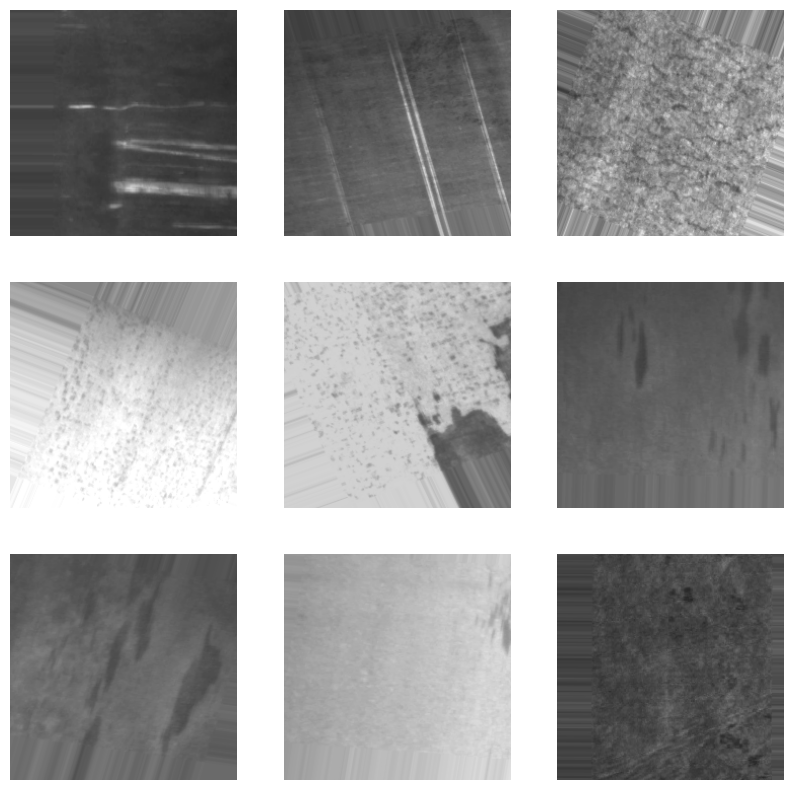

In [59]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [60]:
base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)
)

base_model.trainable = False

In [62]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        train_data.num_classes,
        activation="softmax"
    )
])

In [63]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1
)

In [65]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,710 (10.01 MB)

 Trainable params: 364,166 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [66]:
history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=EPOCHS,

    callbacks=[

        early_stop,

        reduce_lr
    ]
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 446ms/step - accuracy: 0.8118 - loss: 0.5769 - val_accuracy: 0.8444 - val_loss: 0.3806 - learning_rate: 0.0010
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 37s 414ms/step - accuracy: 0.9375 - loss: 0.2093 - val_accuracy: 0.9333 - val_loss: 0.1753 - learning_rate: 0.0010
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 485ms/step - accuracy: 0.9271 - loss: 0.2562 - val_accuracy: 0.9472 - val_loss: 0.1129 - learning_rate: 0.0010
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 36s 401ms/step - accuracy: 0.9417 - loss: 0.2142 - val_accuracy: 0.9333 - val_loss: 0.1456 - learning_rate: 0.0010
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 34s 372ms/step - accuracy: 0.9597 - loss: 0.1283 - val_accuracy: 0.9833 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 37s 407ms/step - accuracy: 0.9590 - loss: 0.1516 - val_accuracy: 0.9722 - val_loss: 0.0783 - learning_rate: 0.0010
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 36s 396ms/step - accuracy: 0.9604 - loss: 0.

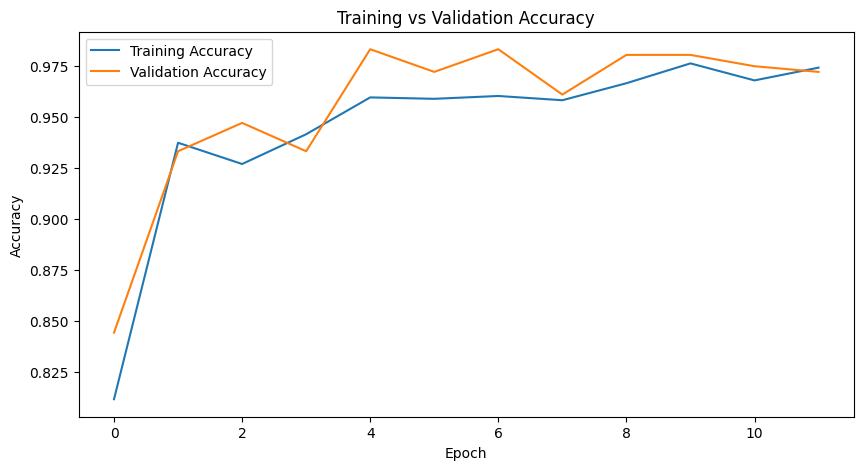

In [67]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

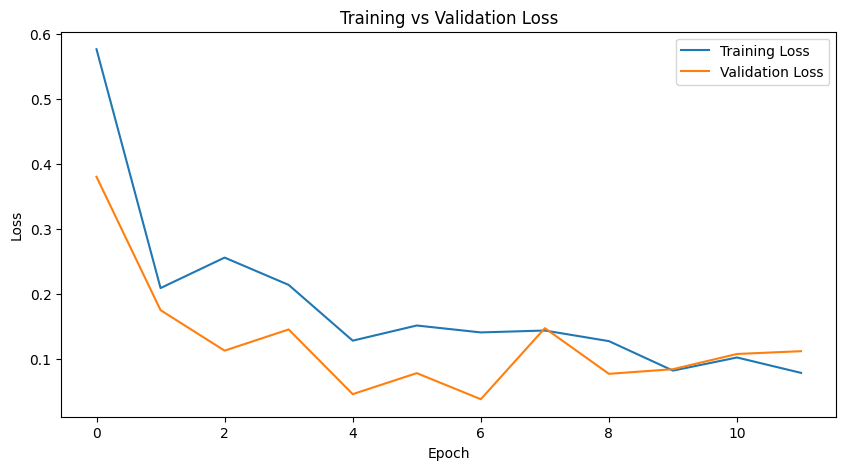

In [68]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [69]:
print(
    "Best Training Accuracy:",
    max(history.history["accuracy"])
)

print(
    "Best Validation Accuracy:",
    max(history.history["val_accuracy"])
)

Best Training Accuracy: 0.9763888716697693
Best Validation Accuracy: 0.9833333492279053


In [70]:
model.save(
    "../backend/model/steel_defect_mobilenet.keras"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [71]:
from tensorflow.keras.models import load_model

test_model = load_model(
    "../backend/model/steel_defect_mobilenet.keras",
    compile=False
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [73]:
import os

print(os.listdir("../dataset/validation/images/scratches")[:20])

['scratches_241.jpg', 'scratches_242.jpg', 'scratches_243.jpg', 'scratches_244.jpg', 'scratches_245.jpg', 'scratches_246.jpg', 'scratches_247.jpg', 'scratches_248.jpg', 'scratches_249.jpg', 'scratches_250.jpg', 'scratches_251.jpg', 'scratches_252.jpg', 'scratches_253.jpg', 'scratches_254.jpg', 'scratches_255.jpg', 'scratches_256.jpg', 'scratches_257.jpg', 'scratches_258.jpg', 'scratches_259.jpg', 'scratches_260.jpg']


In [74]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "../dataset/validation/images/scratches/scratches_242.jpg"

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = test_model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Prediction:",
      class_names[np.argmax(prediction)])

print("Confidence:",
      np.max(prediction) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: scratches
Confidence: 99.999985


In [75]:
from tensorflow.keras.models import load_model

model = load_model(
    "../backend/model/steel_defect_mobilenet.keras",
    compile=False
)

model.save("../backend/model/steel_defect_mobilenet.h5")

print("H5 model saved")

H5 model saved
